In [1]:

# Ques 1: Identify the attributes, their types, distinct values, and range.



import pandas as pd
df = pd.read_csv("Telco-Customer-Churn__1.csv")

#  Identify attributes and their types
attributes = df.columns.tolist()
attribute_types = {}
distinct_values = {}

# Loop over each attribute to determine its type and collect distinct values
for attribute in attributes:
    # Determine attribute type
    dtype = df[attribute].dtype
    
    if pd.api.types.is_numeric_dtype(dtype):
        attribute_types[attribute] = 'Numerical'
        # Calculate range for numerical attributes
        min_value = df[attribute].min()
        max_value = df[attribute].max()
        attribute_range = f"{min_value} - {max_value}"
    else:
        attribute_types[attribute] = 'Categorical'
 # Collect distinct values for categorical attributes and 
#also limiting values to 10 as CustomerID and TotalCharges have many unique values
        distinct_values[attribute] = df[attribute].unique()[:10]

    # Print attribute type and range (if numerical)
    print(f"{attribute}: {attribute_types[attribute]}")
    if pd.api.types.is_numeric_dtype(dtype):
        print(f"   Range: {attribute_range}")

# Print distinct values for categorical attributes
print("\nDistinct values for categorical attributes")
print("limiting values to 10 as CustomerID and TotalCharges have many unique values:")
print('\n')
for attribute, values in distinct_values.items():
    print(f"{attribute}: {', '.join(map(str, values))}")


customerID: Categorical
gender: Categorical
SeniorCitizen: Numerical
   Range: 0 - 1
Partner: Categorical
Dependents: Categorical
tenure: Numerical
   Range: 0 - 72
PhoneService: Categorical
MultipleLines: Categorical
InternetService: Categorical
OnlineSecurity: Categorical
OnlineBackup: Categorical
DeviceProtection: Categorical
TechSupport: Categorical
StreamingTV: Categorical
StreamingMovies: Categorical
Contract: Categorical
PaperlessBilling: Categorical
PaymentMethod: Categorical
MonthlyCharges: Numerical
   Range: 18.25 - 118.75
TotalCharges: Categorical
Churn: Categorical

Distinct values for categorical attributes
limiting values to 10 as CustomerID and TotalCharges have many unique values:


customerID: 7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW, 9237-HQITU, 9305-CDSKC, 1452-KIOVK, 6713-OKOMC, 7892-POOKP, 6388-TABGU
gender: Female, Male
Partner: Yes, No
Dependents: No, Yes
PhoneService: No, Yes
MultipleLines: No phone service, No, Yes
InternetService: DSL, Fiber optic, No
O

<Axes: xlabel='PaymentMethod', ylabel='count'>

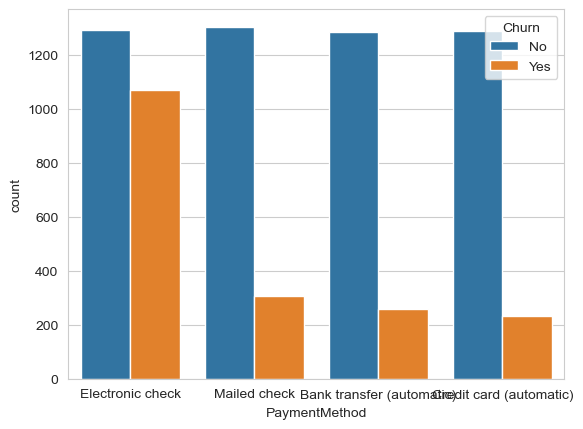

In [9]:
#CountPlot
sns.set_style('whitegrid')
sns.countplot(x='PaymentMethod', data=df,hue= 'Churn')

In [15]:
def tenure_term(size):
    if size in range(1,13):
        return 'Small'
    elif size in range(13,50):
        return 'Medium'
    else:
        return 'Large'

    


In [19]:
df['tenure_size']=df['tenure'].apply(tenure_term)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_size
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Small
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Small
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,Medium
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,Large
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,Small
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes,Small


<Axes: xlabel='tenure_size', ylabel='count'>

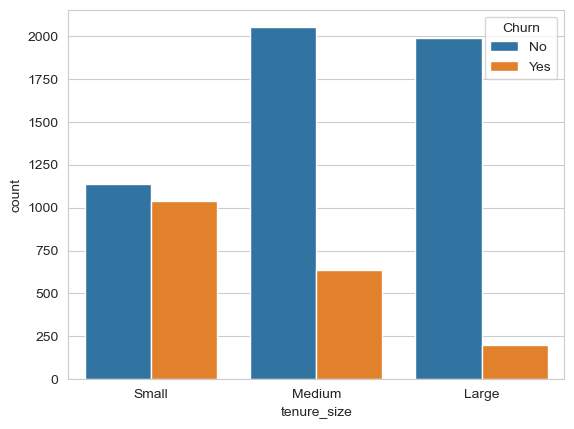

In [23]:
#CountPlot
sns.set_style('whitegrid')
sns.countplot(x='tenure_size', data = df,hue = 'Churn')

<Axes: xlabel='InternetService', ylabel='count'>

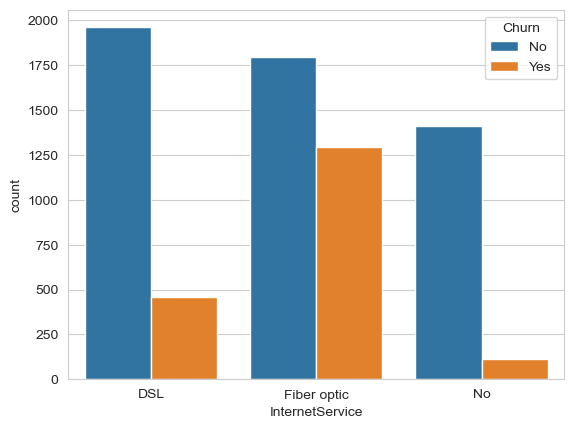

In [25]:
#CountPlot
sns.set_style('whitegrid')
sns.countplot(x='InternetService', data = df,hue = 'Churn')

<Axes: xlabel='PaperlessBilling', ylabel='count'>

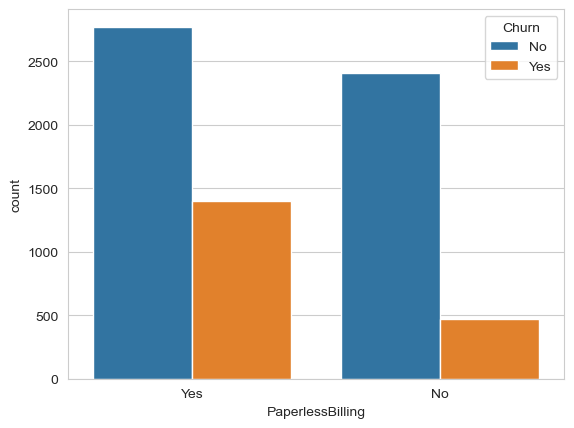

In [27]:
#CountPlot
sns.set_style('whitegrid')
sns.countplot(x='PaperlessBilling', data = df,hue = 'Churn')

<Axes: xlabel='OnlineSecurity', ylabel='count'>

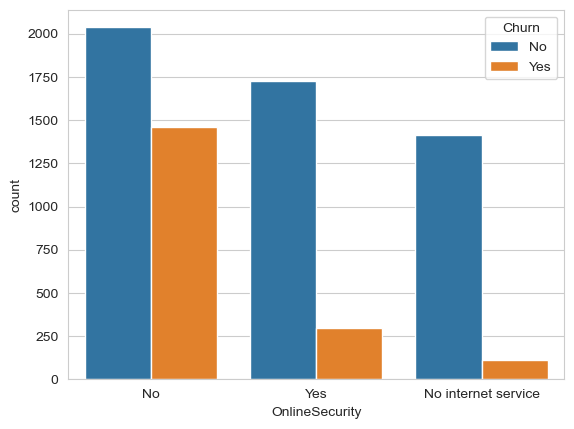

In [29]:
#CountPlot
sns.set_style('whitegrid')
sns.countplot(x='OnlineSecurity', data = df,hue = 'Churn')

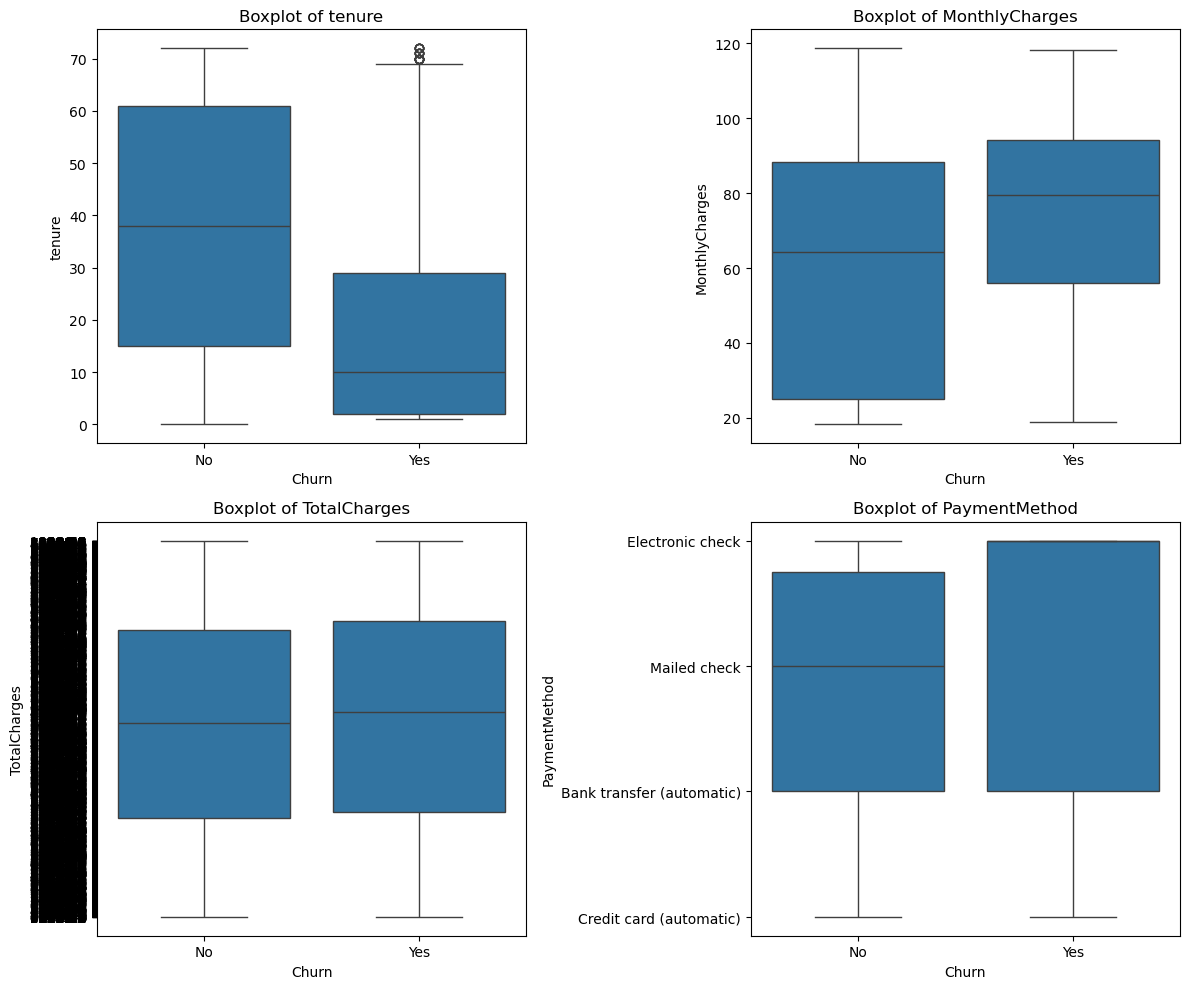

In [5]:
# Ques 2: Create the plots and charts discussed in Chapter 2 (boxplot, histogram, scatter plot, QQ plot, etc.) for different attributes.

# BoxPlot

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


data = pd.read_csv("Telco-Customer-Churn__1.csv")
df = pd.DataFrame(data)
attributes = ['tenure', 'MonthlyCharges', 'TotalCharges','PaymentMethod']
num_plots = len(attributes)
num_cols = 2  
num_rows = (num_plots + 1) // num_cols 
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 10))
axes = axes.flatten()

for i, attribute in enumerate(attributes):
    sns.boxplot(x='Churn', y=attribute, data=df, ax=axes[i])
    axes[i].set_title(f'Boxplot of {attribute}')

for j in range(i+1, num_cols * num_rows):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


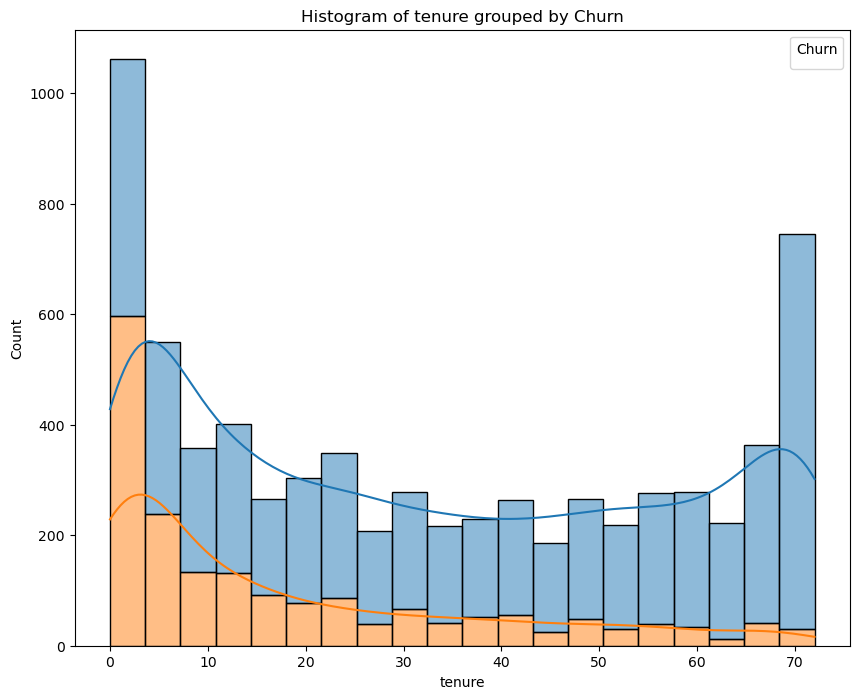

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


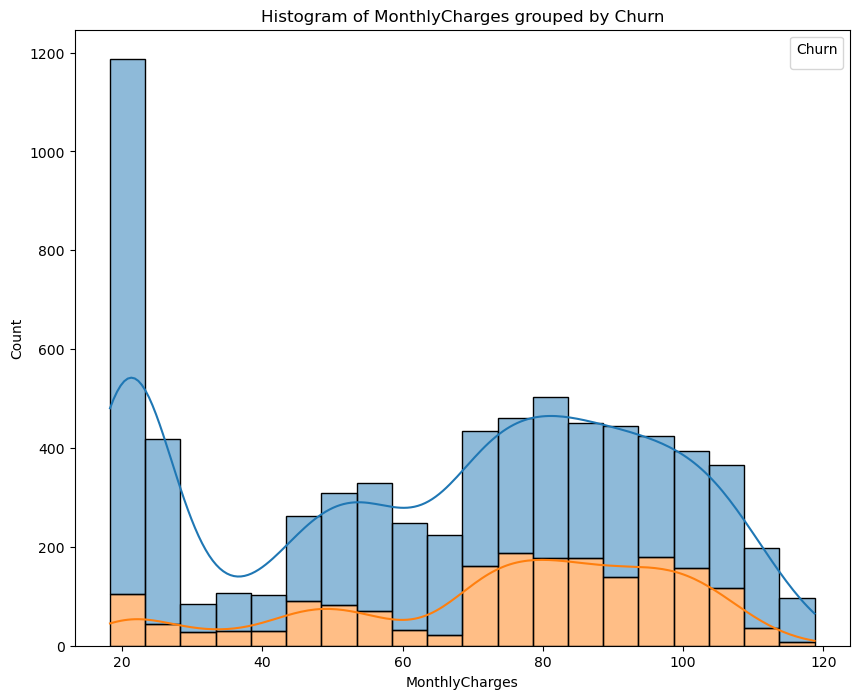

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


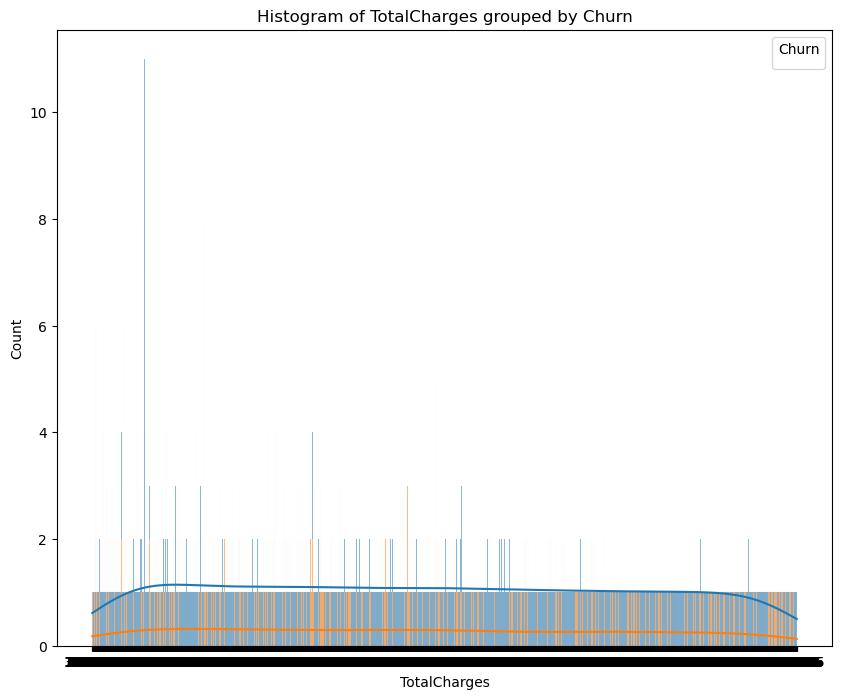

In [5]:
# Ques 2: Create the plots and charts discussed in Chapter 2 (boxplot, histogram, scatter plot, QQ plot, etc.) for different attributes.

# Histogram

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example dataframe (replace with your actual dataset)
data = pd.read_csv("Telco-Customer-Churn__1.csv")
df = pd.DataFrame(data)

# Define numerical and categorical attributes
numerical_attributes = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_attributes = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
                          'PhoneService', 'MultipleLines', 'InternetService', 
                          'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                          'TechSupport', 'StreamingTV', 'StreamingMovies', 
                          'Contract', 'PaperlessBilling', 'PaymentMethod']

# Plot histograms for numerical attributes against Churn
for attr in numerical_attributes:
    plt.figure(figsize=(10, 8))
    sns.histplot(data=df, x=attr, hue='Churn', multiple='stack', bins=20, kde=True)
    plt.title(f'Histogram of {attr} grouped by Churn')
    plt.xlabel(attr)
    plt.ylabel('Count')
    plt.legend(title='Churn', loc='upper right')
    plt.show()



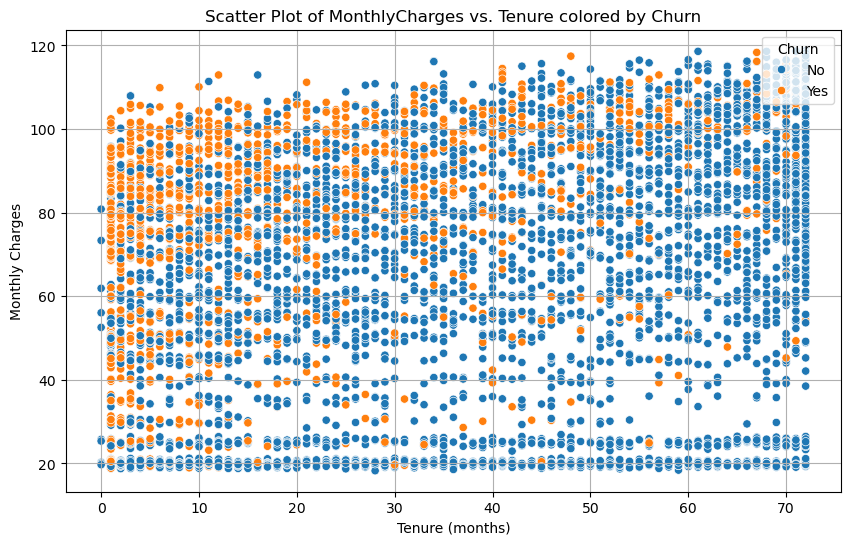

In [7]:
# Ques 2: Create the plots and charts discussed in Chapter 2 (boxplot, histogram, scatter plot, QQ plot, etc.) for different attributes.

# Scatter plot

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("Telco-Customer-Churn__1.csv")

df = pd.DataFrame(data)

# Scatter plot of MonthlyCharges vs. tenure, colored by Churn
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn')
plt.title('Scatter Plot of MonthlyCharges vs. Tenure colored by Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges')
plt.legend(title='Churn', loc='upper right')
plt.grid(True)
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\graphics\gofplots.py:1043: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


<Figure size 800x600 with 0 Axes>

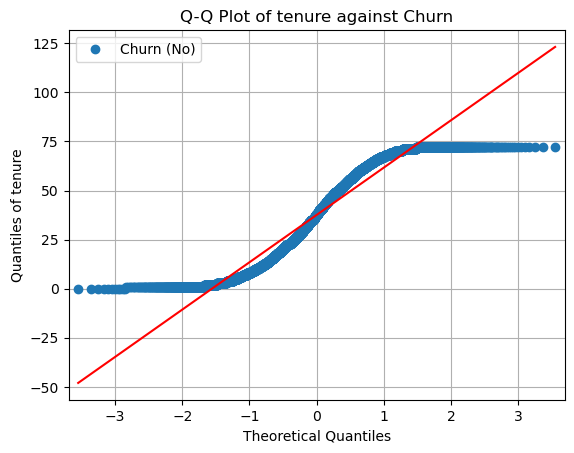

<Figure size 800x600 with 0 Axes>

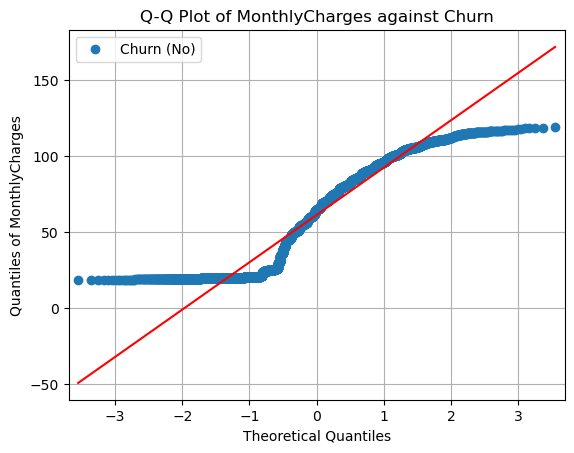

In [9]:
# Ques 2: Create the plots and charts discussed in Chapter 2 (boxplot, histogram, scatter plot, QQ plot, etc.) for different attributes.

# Q-Q Plot

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

data = pd.read_csv("Telco-Customer-Churn__1.csv")
df = pd.DataFrame(data)

# Select numerical attributes
numerical_attributes = ['tenure', 'MonthlyCharges']

for attr in numerical_attributes:
    plt.figure(figsize=(8, 6))
    
    # Separate data for Churn and No Churn
    churn_data = df[df['Churn'] == 'Yes'][attr]
    no_churn_data = df[df['Churn'] == 'No'][attr]
    
    # Generate Q-Q plot
    sm.qqplot(no_churn_data, line='s', label='Churn (No)', marker='o', color='red')
    
    plt.title(f'Q-Q Plot of {attr} against Churn')
    plt.xlabel('Theoretical Quantiles')
    plt.ylabel(f'Quantiles of {attr}')
    plt.legend()
    plt.grid(True)
    plt.show()


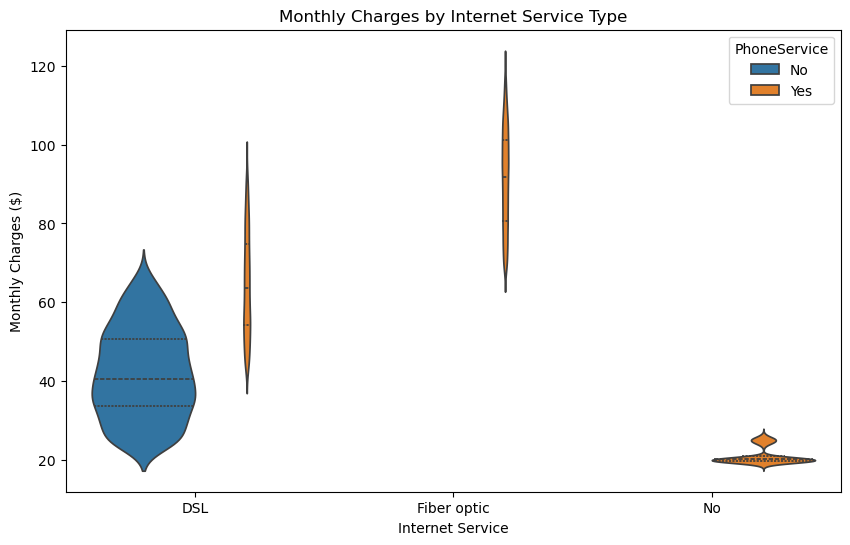

In [5]:
# Ques 2: Create the plots and charts discussed in Chapter 2 (boxplot, histogram, scatter plot, QQ plot, etc.) for different attributes.

# Violin Plot

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example data (replace with your actual dataset)
data = pd.read_csv("Telco-Customer-Churn__1.csv")

df = pd.DataFrame(data)

# Create violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='InternetService', y='MonthlyCharges', hue='PhoneService',data=df, inner='quartile')
plt.title('Monthly Charges by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Monthly Charges ($)')
plt.show()

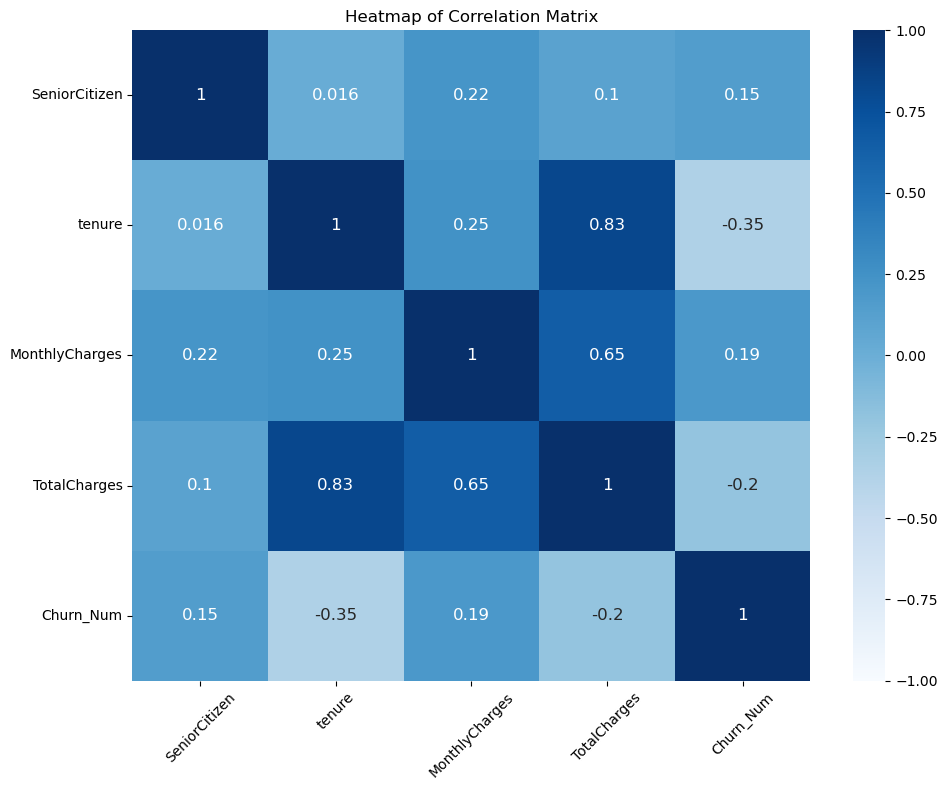

In [9]:
# Ques 3: Try to find which type of customers are more likely to churn.

# HeatMap

# Ans: Based on the Correlation by heatmap shows that where 
#monthly_charges are above 100 are likely to churn.


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("Telco-Customer-Churn__1.csv")
df = pd.DataFrame(data)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with NaN values in 'TotalCharges' column
df.dropna(subset=['TotalCharges'], inplace=True)

# Convert Churn to binary numeric values for heatmap plotting (1 for Yes, 0 for No)
df['Churn_Num'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

heatmap_attributes = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Num']

# Calculate correlation matrix
corr_matrix = df[heatmap_attributes].corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Blues',vmin=-1,vmax=1, annot_kws={'size': 12})
plt.title('Heatmap of Correlation Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()